In [1]:
  import tensorflow as tf
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  import os

In [2]:
!mkdir /root/.kaggle
!mv kaggle.json /root/.kaggle

In [3]:
!kaggle competitions download -c plant-pathology-2020-fgvc7

 98% 767M/779M [00:06<00:00, 128MB/s]
100% 779M/779M [00:07<00:00, 115MB/s]


In [4]:
!unzip -q plant-pathology-2020-fgvc7.zip

In [ ]:
len(os.listdir("images"))

3642

In [5]:

df_train=pd.read_csv("train.csv")
df_train['image_id'] =df_train['image_id'] +".jpg"
#df_train['healthy']=df_train['healthy'].map({1:'yes',0:'No'})
labels=[]
for i in range(len(df_train)):
  if df_train.loc[i,"healthy"]==1:
    labels.append("healthy")
  elif   df_train.loc[i,"multiple_diseases"]==1:
    labels.append("multiple_diseases")
  elif   df_train.loc[i,"rust"]==1:
    labels.append("rust")
  else:
    labels.append("scab")

df_train["label"]=labels
df_train.head()

,image_id,healthy,multiple_diseases,rust,scab,label
0,Train_0.jpg,0,0,0,1,scab
1,Train_1.jpg,0,1,0,0,multiple_diseases
2,Train_2.jpg,1,0,0,0,healthy
3,Train_3.jpg,0,0,1,0,rust
4,Train_4.jpg,1,0,0,0,healthy


In [ ]:
import cv2
imagenames=[]
height=[]
width=[]
dim=[]
for image in os.listdir("images/"):
      imagenames.append(image)
      img = "images/" + image
      imag = cv2.cvtColor(cv2.imread(img), cv2.COLOR_BGR2RGB)
      height.append(imag.shape[0])
      width.append(imag.shape[1])
      dim.append(imag.shape[2])

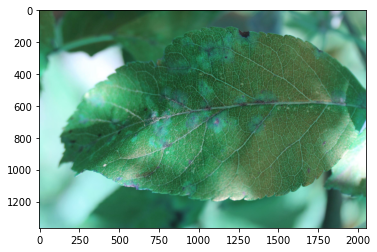

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
num=np.random.randint(0,3642)
image1=cv2.imread("images/" + imagenames[num])
plt.imshow(image1)


In [ ]:
import statistics as st
print("Average image height",st.mean(height))
print("Average image width",st.mean(width))

Average image height 1369.1257550796265
Average image width 2043.8742449203735


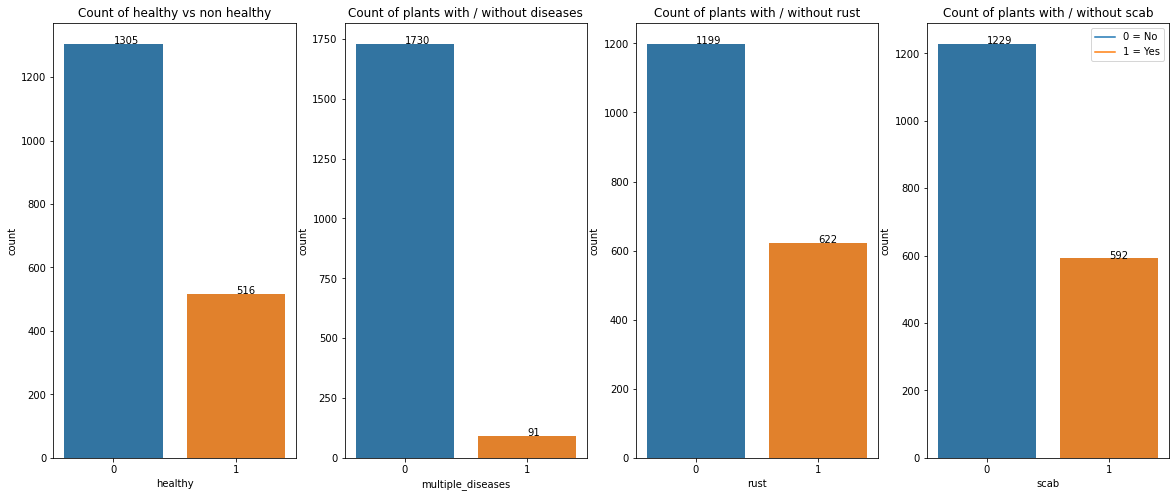

In [ ]:
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize=(20,8))
plt.subplot(1,4,1)
sns.countplot(df_train['healthy'])
plt.title("Count of healthy vs non healthy")
plt.plot(0, label ="0 = No")
plt.plot(1, label ="1 = Yes")
for v in [0, 1]:
    plt.text(v, (df_train.healthy == v).sum(), str((df_train.healthy == v).sum()));
plt.subplot(1,4,2)
sns.countplot(df_train['multiple_diseases'])
plt.title("Count of plants with / without diseases")
plt.plot(0, label ="0 = No")
plt.plot(1, label ="1 = Yes")
for v in [0, 1]:
    plt.text(v, (df_train.multiple_diseases == v).sum(), str((df_train.multiple_diseases == v).sum()));
plt.subplot(1,4,3)
sns.countplot(df_train['rust'])
plt.title("Count of plants with / without rust")
plt.plot(0, label ="0 = No")
plt.plot(1, label ="1 = Yes")
for v in [0, 1]:
    plt.text(v, (df_train.rust == v).sum(), str((df_train.rust == v).sum()));
plt.subplot(1,4,4)
sns.countplot(df_train['scab'])
plt.title("Count of plants with / without scab")
plt.plot(0, label ="0 = No")
plt.plot(1, label ="1 = Yes")
for v in [0, 1]:
    plt.text(v, (df_train.scab == v).sum(), str((df_train.scab == v).sum()));

plt.legend()
plt.show()



In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
from sklearn.model_selection import train_test_split
train,test=train_test_split(df_train,test_size=0.30)

In [8]:
idg = ImageDataGenerator(rescale=1/255.0,rotation_range=60,zoom_range=2.0,brightness_range=(30,60),validation_split=0.1)

In [9]:
train_gen=idg.flow_from_dataframe(train,directory="images",x_col='image_id',y_col=['healthy','multiple_diseases','rust','scab'],class_mode='raw',subset='training',target_size=(512,512))

Found 1147 validated image filenames.


In [10]:
val_gen=idg.flow_from_dataframe(train,directory="images",x_col='image_id',y_col='label',subset='validation',target_size=(512,512))

Found 127 validated image filenames belonging to 4 classes.


In [ ]:
# Below model takes very very long time due to the large number of parameters.

In [ ]:
import tensorflow as tf
model3 = tf.keras.models.Sequential()
model3.add(tf.keras.layers.Input(shape=(1000,1000, 3)))
# Chunk 1 
model3.add(tf.keras.layers.Conv2D(filters=8, kernel_size=(3,3), strides=(1,1), 
                                 activation = tf.keras.activations.relu))
model3.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(2,2)))  

# Chunk 2 
model3.add(tf.keras.layers.Conv2D(16, kernel_size=(3,3), strides=(1,1), 
                                 activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Chunk 3 
model3.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), strides=(1,1), 
                                 activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(2,2)))

# Chunk 4 
model3.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), strides=(1,1), 
                                 activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(2,2)))


# Chunk 5 
model3.add(tf.keras.layers.Conv2D(128, kernel_size=(3,3), strides=(1,1), 
                                 activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(2,2)))



# Chunk 5 
model3.add(tf.keras.layers.Conv2D(256, kernel_size=(3,3), strides=(1,1), 
                                 activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(2,2)))




model3.add(tf.keras.layers.Flatten())
model3.add(tf.keras.layers.Dense(256, activation=tf.keras.activations.relu))
#model3.add(tf.keras.layers.Dense(128, activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.Dense(2, activation=tf.keras.activations.softmax))
model3.summary()
model3.compile(tf.keras.optimizers.SGD(), 
              loss=tf.keras.losses.categorical_crossentropy, 
              metrics=["acc"])
hist3 = model3.fit(train_gen, batch_size=32, epochs=25, validation_data=val_gen)

In [ ]:
del model3
model3 = tf.keras.models.Sequential()
model3.add(tf.keras.layers.Input(shape=(512,512, 3)))
# Chunk 1 

# Chunk 2 2
model3.add(tf.keras.layers.Conv2D(256, kernel_size=(3,3), strides=(1,1), 
                                 activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(1,1)))  

# Chunk 3 
model3.add(tf.keras.layers.Conv2D(128, kernel_size=(3,3), strides=(1,1), 
                                 activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(1,1)))  

# Chunk 4 
model3.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3), strides=(1,1), 
                                 activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(1,1)))  


# Chunk 5 
model3.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), strides=(2,2), 
                                 activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(1,1)))  



# Chunk 5 
model3.add(tf.keras.layers.Conv2D(16, kernel_size=(3,3), strides=(2,2), 
                                 activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.MaxPool2D(pool_size=(2,2), strides=(1,1))))  





model3.add(tf.keras.layers.Flatten())
model3.add(tf.keras.layers.Dense(256, activation=tf.keras.activations.relu))
#model3.add(tf.keras.layers.Dense(128, activation=tf.keras.activations.relu))
model3.add(tf.keras.layers.Dense(2, activation=tf.keras.activations.softmax))
model3.summary()


In [ ]:
model3.compile(tf.keras.optimizers.SGD(), 
              loss=tf.keras.losses.categorical_crossentropy, 
              metrics=["acc"])
hist3 = model3.fit(train_gen, batch_size=10, epochs=25, validation_data=val_gen)

Epoch 1/25


ResourceExhaustedError: ignored

In [ ]:
del model6
from tensorflow.keras import applications
vgg2 = applications.VGG16(include_top=False, input_shape=(512,512, 3))
vgg2.summary()
for layer in vgg2.layers:
  layer.trainable = False
flat = tf.keras.layers.Flatten() (vgg2.output) 
d1 = tf.keras.layers.Dense(256, activation='relu') (flat)
#d2 = tf.keras.layers.Dense(128, activation='relu') (d1)
pred = tf.keras.layers.Dense(4, activation='softmax') (d1)
model6 = tf.keras.Model(inputs=[vgg2.input], outputs=[pred])
model6.compile(tf.keras.optimizers.SGD(), loss=tf.keras.losses.categorical_crossentropy, metrics=["acc"]) 
early_stopping=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=5)
redu_lr=tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=5, min_lr=0.01)
model6.fit(train_gen, validation_data=val_gen, epochs=10, batch_size=16,callbacks=[early_stopping,redu_lr])    

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 512, 512, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 512, 512, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 512, 512, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 256, 256, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 256, 256, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 256, 256, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 128, 128, 128)     0     

In [ ]:
model6.save("Plant")
new_model=tf.keras.models.load_model("Plant")
test=test.reset_index()
test

INFO:tensorflow:Assets written to: Plant/assets


,index,image_id,healthy,multiple_diseases,rust,scab,label
0,871,Train_871.jpg,0,0,0,1,scab
1,292,Train_292.jpg,0,0,0,1,scab
2,1746,Train_1746.jpg,0,0,1,0,rust
3,964,Train_964.jpg,0,0,0,1,scab
4,915,Train_915.jpg,1,0,0,0,healthy
...,...,...,...,...,...,...,...
542,55,Train_55.jpg,1,0,0,0,healthy
543,1808,Train_1808.jpg,1,0,0,0,healthy
544,1755,Train_1755.jpg,0,0,1,0,rust
545,926,Train_926.jpg,0,0,0,1,scab


In [ ]:
actual_labels=[]
for i in range(len(test)):
  if test.loc[i,"label"]=="healthy":
    actual_labels.append(0)
  elif   test.loc[i,"label"]=="multiple_diseases":
    actual_labels.append(1)
  elif   test.loc[i,"label"]=="rust":
    actual_labels.append("2")
  else:
    actual_labels.append("3")
test["actual"]=actual_labels
test.actual=test.actual.astype("int")
test

,index,image_id,healthy,multiple_diseases,rust,scab,label,actual
0,871,Train_871.jpg,0,0,0,1,scab,3
1,292,Train_292.jpg,0,0,0,1,scab,3
2,1746,Train_1746.jpg,0,0,1,0,rust,2
3,964,Train_964.jpg,0,0,0,1,scab,3
4,915,Train_915.jpg,1,0,0,0,healthy,0
...,...,...,...,...,...,...,...,...
542,55,Train_55.jpg,1,0,0,0,healthy,0
543,1808,Train_1808.jpg,1,0,0,0,healthy,0
544,1755,Train_1755.jpg,0,0,1,0,rust,2
545,926,Train_926.jpg,0,0,0,1,scab,3


In [ ]:
import cv2
import numpy as np
predicted_labels=[]
for i in range(len(test)):
 image=test.loc[i,"image_id"]
 image=cv2.cvtColor(cv2.imread("images/"+image),cv2.COLOR_BGR2RGB)
 image=image/255.0  # data preprocessing
 image=cv2.resize(image,(512,512))
 image=np.expand_dims(image,axis=0)
 predicted_labels.append(np.argmax(model6.predict(image)))
predicted_labels
test["pred"]=predicted_labels
test

,index,image_id,healthy,multiple_diseases,rust,scab,label,actual,pred
0,871,Train_871.jpg,0,0,0,1,scab,3,2
1,292,Train_292.jpg,0,0,0,1,scab,3,2
2,1746,Train_1746.jpg,0,0,1,0,rust,2,2
3,964,Train_964.jpg,0,0,0,1,scab,3,2
4,915,Train_915.jpg,1,0,0,0,healthy,0,2
...,...,...,...,...,...,...,...,...,...
542,55,Train_55.jpg,1,0,0,0,healthy,0,2
543,1808,Train_1808.jpg,1,0,0,0,healthy,0,2
544,1755,Train_1755.jpg,0,0,1,0,rust,2,2
545,926,Train_926.jpg,0,0,0,1,scab,3,2


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(confusion_matrix(test.pred,test.actual)) # Confusion Matrix
accuracy_score(test.actual,test.pred)
print(classification_report(test.pred,test.actual))

[[  0   0   0   0]
 [  0   0   0   0]
 [171  38 189 149]
 [  0   0   0   0]]


0.34552102376599636

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         0
           2       1.00      0.35      0.51       547
           3       0.00      0.00      0.00         0

    accuracy                           0.35       547
   macro avg       0.25      0.09      0.13       547
weighted avg       1.00      0.35      0.51       547



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
def prediction(input_image):
 image=cv2.cvtColor(cv2.imread("images/"+input_image),cv2.COLOR_BGR2RGB)
 image=image/255.0  # data preprocessing
 image=cv2.resize(image,(512,512))
 image=np.expand_dims(image,axis=0)

 z=np.argmax(new_model.predict(image))
 actual=test[test.image_id==input_image].actual
 actual=np.array(actual)
 acc_score=accuracy_score(actual,np.array([z]))

 if z==0:
   print("The leaf is healthy!")
 elif z==1:
   print("The leaf has multiple diseases!")
 elif z==2:
    print("The leaf has rust")	
 else:
   print("The leaf has scabs")
 print("The accuracy of prediction is:",acc_score)  

prediction("Train_1625.jpg")

ValueError: ignored

In [15]:
import tensorflow as tf
dense=tf.keras.applications.densenet.DenseNet121(include_top=False,
                                               weights='imagenet',
                                               input_shape=(512,512,3))
                                          
for layer in dense.layers:
  layer.trainable=False

x=dense.output
x=tf.keras.layers.BatchNormalization()(x)
x=tf.keras.layers.GlobalAveragePooling2D()(x)
#x=tf.keras.layers.Dense(512,activation="relu")(x)
x=tf.keras.layers.Dropout(0.2)(x)
pred=tf.keras.layers.Dense(4,activation="softmax")(x)
model=tf.keras.Model(inputs=dense.input,outputs=pred)

model.compile(tf.keras.optimizers.RMSprop(),
              loss="categorical_crossentropy",
              metrics=["acc"])
early_stopping=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=5)
redu_lr=tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=5, min_lr=0.01)
tftb=tf.keras.callbacks.TensorBoard(log_dir="logs")
hist=model.fit(train_gen,validation_data=val_gen,epochs=10,batch_size=16,callbacks=[early_stopping,redu_lr,tftb])

Epoch 1/10
36/36 [==============================] - 190s 5s/step - loss: 1.2895 - acc: 0.3470 - val_loss: 1.4054 - val_acc: 0.3228 - lr: 0.0010
Epoch 2/10
36/36 [==============================] - 157s 4s/step - loss: 1.2294 - acc: 0.4002 - val_loss: 1.3209 - val_acc: 0.3071 - lr: 0.0010
Epoch 3/10
36/36 [==============================] - 157s 4s/step - loss: 1.2345 - acc: 0.3670 - val_loss: 1.2816 - val_acc: 0.3465 - lr: 0.0010
Epoch 4/10
36/36 [==============================] - 158s 4s/step - loss: 1.2274 - acc: 0.3740 - val_loss: 1.2286 - val_acc: 0.3543 - lr: 0.0010
Epoch 5/10
36/36 [==============================] - 156s 4s/step - loss: 1.2232 - acc: 0.3915 - val_loss: 1.2463 - val_acc: 0.3150 - lr: 0.0010
Epoch 6/10
36/36 [==============================] - 158s 4s/step - loss: 1.2293 - acc: 0.3740 - val_loss: 1.2264 - val_acc: 0.3937 - lr: 0.0010
Epoch 7/10
36/36 [==============================] - 161s 4s/step - loss: 1.2176 - acc: 0.3880 - val_loss: 1.2248 - val_acc: 0.3937 - lr:

In [16]:
model.save("Plant1")
new_model=tf.keras.models.load_model("Plant1")
test=test.reset_index()
test

INFO:tensorflow:Assets written to: Plant1/assets


,index,image_id,healthy,multiple_diseases,rust,scab,label
0,846,Train_846.jpg,0,0,0,1,scab
1,240,Train_240.jpg,0,0,1,0,rust
2,1018,Train_1018.jpg,0,1,0,0,multiple_diseases
3,882,Train_882.jpg,1,0,0,0,healthy
4,1172,Train_1172.jpg,0,0,0,1,scab
...,...,...,...,...,...,...,...
542,1211,Train_1211.jpg,0,0,0,1,scab
543,993,Train_993.jpg,0,0,0,1,scab
544,1631,Train_1631.jpg,1,0,0,0,healthy
545,927,Train_927.jpg,0,0,0,1,scab


In [17]:
actual_labels=[]
for i in range(len(test)):
  if test.loc[i,"label"]=="healthy":
    actual_labels.append(0)
  elif   test.loc[i,"label"]=="multiple_diseases":
    actual_labels.append(1)
  elif   test.loc[i,"label"]=="rust":
    actual_labels.append("2")
  else:
    actual_labels.append("3")
test["actual"]=actual_labels
test.actual=test.actual.astype("int")
test

,index,image_id,healthy,multiple_diseases,rust,scab,label,actual
0,846,Train_846.jpg,0,0,0,1,scab,3
1,240,Train_240.jpg,0,0,1,0,rust,2
2,1018,Train_1018.jpg,0,1,0,0,multiple_diseases,1
3,882,Train_882.jpg,1,0,0,0,healthy,0
4,1172,Train_1172.jpg,0,0,0,1,scab,3
...,...,...,...,...,...,...,...,...
542,1211,Train_1211.jpg,0,0,0,1,scab,3
543,993,Train_993.jpg,0,0,0,1,scab,3
544,1631,Train_1631.jpg,1,0,0,0,healthy,0
545,927,Train_927.jpg,0,0,0,1,scab,3


In [20]:
import cv2
import numpy as np
predicted_labels=[]
for i in range(len(test)):
 image=test.loc[i,"image_id"]
 image=cv2.cvtColor(cv2.imread("images/"+image),cv2.COLOR_BGR2RGB)
 image=image/255.0  # data preprocessing
 image=cv2.resize(image,(512,512))
 image=np.expand_dims(image,axis=0)
 predicted_labels.append(np.argmax(model.predict(image)))
predicted_labels
test["pred"]=predicted_labels
test

,index,image_id,healthy,multiple_diseases,rust,scab,label,actual,pred
0,846,Train_846.jpg,0,0,0,1,scab,3,0
1,240,Train_240.jpg,0,0,1,0,rust,2,3
2,1018,Train_1018.jpg,0,1,0,0,multiple_diseases,1,3
3,882,Train_882.jpg,1,0,0,0,healthy,0,0
4,1172,Train_1172.jpg,0,0,0,1,scab,3,0
...,...,...,...,...,...,...,...,...,...
542,1211,Train_1211.jpg,0,0,0,1,scab,3,0
543,993,Train_993.jpg,0,0,0,1,scab,3,0
544,1631,Train_1631.jpg,1,0,0,0,healthy,0,0
545,927,Train_927.jpg,0,0,0,1,scab,3,0


In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(confusion_matrix(test.pred,test.actual)) # Confusion Matrix
accuracy_score(test.actual,test.pred)
print(classification_report(test.pred,test.actual))

[[126  22 145 149]
 [  0   0   0   0]
 [  4   4  11   2]
 [ 28   3  16  37]]
              precision    recall  f1-score   support

           0       0.80      0.29      0.42       442
           1       0.00      0.00      0.00         0
           2       0.06      0.52      0.11        21
           3       0.20      0.44      0.27        84

    accuracy                           0.32       547
   macro avg       0.26      0.31      0.20       547
weighted avg       0.68      0.32      0.39       547



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [30]:
def prediction(input_image):
 image=cv2.cvtColor(cv2.imread("images/"+input_image),cv2.COLOR_BGR2RGB)
 image=image/255.0  # data preprocessing
 image=cv2.resize(image,(512,512))
 image=np.expand_dims(image,axis=0)

 z=np.argmax(new_model.predict(image))
 print(z)
 actual=test[test.image_id==input_image].actual
 actual=np.array(actual)
 print(actual)
 acc_score=accuracy_score(actual,np.array([z]))
 print("hello")
 if z==0:
   print("The leaf is healthy!")
 elif z==1:
   print("The leaf has multiple diseases!")
 elif z==2:
    print("The leaf has rust")	
 else:
   print("The leaf has scabs")
 print("The accuracy of prediction is:",acc_score)  

prediction("Test_1620.jpg")

0
[]


ValueError: ignored